# Urban Heat Island & Land-Use Change Analysis
## Kathmandu Valley & Hetauda, Nepal &nbsp;·&nbsp; 2015 – 2025

---
This study provides a comparative remote-sensing assessment of Surface Urban Heat Island (SUHI) dynamics and Land-Use/Land-Cover (LULC) changes across two distinct urban centers in Nepal from **2015 to 2025**:
* **Kathmandu:** A dense, mature urban core experiencing high-density inward and outward expansion.
* **Hetauda:** A smaller, rapidly developing industrial and regional hub.


### Contents

| # | Section | Produces | Research question |
|---|---|---|---|
| 1 | LULC Transition Matrix | km² converted between land-cover classes, 2015 → 2025 | **Q1** — what land became built-up? |
| 2 | UHI Zone Transition Matrix | km² shifted between heat-intensity zones | **Q2** — how did the heat footprint change? |
| 3 | SUHII Trend | Urban − rural LST gap, per year, per city | **Q2 / Q4** — is the heat island intensifying? |
| 4 | Map Visuals | LULC, LST, ΔLST, UHI-zone, and change maps | — |
| 5 | LULC × LST Overlay | Warming by land-cover trajectory | **Q4** — does urbanization *cause* local warming? |
| 6 | Trend Charts | Area % and mean LST per class, over time | — |

---
### Data layout

Matches the structure of the source dataset (set `BASE` below to point at local `Maps` folder):

```
Datasets/
├── LST Maps/
│   └── {City}_LST_raw_{Year}.tif
├── UHI Maps/
│   └── {City}_UHI_Hotspots_raw_{Year}.tif
└── UHI_LST_ML_Dataset/
    ├── {City}_LULC_raw_{Year}.tif
    ├── LULC_Area_Stats_{City}.csv
    └── LULC_LST_Relationship_{City}.csv
```

### Requirements

```
pip install rasterio numpy pandas matplotlib
```

---
### Methodological Highlights
* **Grid Alignment:** To perform pixel-level overlay analysis, finer-resolution LULC classifications ($10\text{ m}$) were reprojected onto coarser Land Surface Temperature ($30\text{ m}$) grids using **majority (mode) resampling**. This preserves categorical integrity without interpolating or inventing unassigned class codes.
* **Metric Framework:** The analysis integrates LULC transition matrices, UHI intensity-zone shifts (categorized from *Cool* to *Hotspot* using perceptually uniform colormaps like `inferno`), and annual Standardized Urban Heat Island Intensity (SUHII) trends to isolate true heat-island development from seasonal or regional temperature anomalies.

### How to read the results

> **Section 3 (SUHII)** is the most statistically robust evidence in this notebook. It always compares urban vs. rural pixels *within the same year*, so it isn't confounded by year-to-year seasonal or atmospheric differences the way the raw ΔLST overlay in Section 5 can be — see the caveat note after Section 5 before citing that section's numbers as causal evidence.


## 0 · Setup & Configuration

In [1]:
# ── Core scientific / geospatial stack ──────────────────────────────────────
import os
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Path configuration ───────────────────────────────────────────────────────
BASE = "../data/raw"

CITIES = ["Kathmandu", "Hetauda"]
YEARS = [2015, 2020, 2025]

# ── Land-cover class definitions ────────────────────────────────────────────
CLASS_NAMES = ["Builtup", "Vegetation", "Agriculture", "Water", "BareLand"]
CLASS_CODES = [0, 1, 2, 3, 4]
CODE_TO_NAME = dict(zip(CLASS_CODES, CLASS_NAMES))

CLASS_COLORS = {
    "Builtup":     "#B0142A",  # brick red    - impervious / urban fabric
    "Vegetation":  "#1B7A3D",  # forest green - dense tree cover
    "Agriculture": "#C9A227",  # ochre/olive  - cropland
    "Water":       "#1F6FB2",  # cobalt blue  - rivers, ponds, reservoirs
    "BareLand":    "#D9B382",  # sand/tan     - exposed soil, construction sites
}
CLASS_PALETTE = [CLASS_COLORS[name] for name in CLASS_NAMES]

# ── UHI intensity-zone definitions ──────────────────────────────────────────
ZONE_NAMES = ["Cool", "Moderately Cool", "Moderate", "Warm", "Hotspot"]
ZONE_CODE_TO_NAME = dict(zip(range(5), ZONE_NAMES))

ZONE_COLORS = {
    "Cool":            "#313695",
    "Moderately Cool": "#74ADD1",
    "Moderate":        "#FEE090",
    "Warm":            "#F46D43",
    "Hotspot":         "#A50026",
}
ZONE_PALETTE = [ZONE_COLORS[name] for name in ZONE_NAMES]

# ── Colormaps for continuous rasters ────────────────────────────────────────
LST_CMAP = "inferno"
DIFF_CMAP = "RdBu_r"

# ── Per-city accent colors, reused everywhere a chart compares the two cities ─
CITY_COLORS = {"Kathmandu": "#264653", "Hetauda": "#E76F51"}

# ── Global plot styling -- consistent, publication-quality look throughout ──
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.titlesize": 15,
    "figure.titleweight": "bold",
    "axes.edgecolor": "#444444",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

MAP_FIGSIZE = (16, 6)          # 3-panel year-comparison maps
SINGLE_MAP_FIGSIZE = (8, 7)    # single-panel maps


In [2]:
def load_raster(path: str) -> tuple[np.ndarray, float]:
    """Load a single-band raster and compute its pixel area in km².

    Parameters
    ----------
    path : str
        Path to a GeoTIFF raster.

    Returns
    -------
    arr : np.ndarray
        The raster's first band.
    pixel_area_km2 : float
        Approximate area of one pixel, in km², based on the raster's
        resolution and its central latitude (accounts for the shrinking of
        longitude degrees away from the equator).
    """
    with rasterio.open(path) as src:
        arr = src.read(1)
        transform = src.transform
        px_w, px_h = abs(transform[0]), abs(transform[4])
        center_lat = (src.bounds.top + src.bounds.bottom) / 2
        km_per_deg_lat = 111.32
        km_per_deg_lon = 111.32 * np.cos(np.radians(center_lat))
        pixel_area_km2 = (px_w * km_per_deg_lon) * (px_h * km_per_deg_lat)
    return arr, pixel_area_km2


def lulc_path(city: str, year: int) -> str:
    """Path to a city's classified LULC raster for a given year."""
    return f"{BASE}/{city.lower()}/lulc_tifs/{city}_LULC_raw_{year}.tif"


def lst_path(city: str, year: int) -> str:
    """Path to a city's Land Surface Temperature raster for a given year."""
    return f"{BASE}/{city.lower()}/lst_tifs/{city}_LST_raw_{year}.tif"


def uhi_path(city: str, year: int) -> str:
    """Path to a city's UHI intensity-zone raster for a given year."""
    return f"{BASE}/{city.lower()}/uhi_tifs/{city}_UHI_Hotspots_raw_{year}.tif"


def align_lulc_to_lst(city: str, year: int) -> np.ndarray:
    """Reproject the finer-resolution LULC raster onto the LST grid.

    LST rasters are typically coarser (~30 m) than LULC classifications
    (~10 m), so a pixel-by-pixel overlay requires resampling LULC onto the
    LST grid first. Majority ("mode") resampling is used, which is the
    correct choice for categorical data -- unlike bilinear/cubic
    interpolation, it never invents a class that isn't in the source data.
    """
    with rasterio.open(lulc_path(city, year)) as lulc_src:
        lulc_arr = lulc_src.read(1)
        lulc_transform = lulc_src.transform
        lulc_crs = lulc_src.crs
    with rasterio.open(lst_path(city, year)) as lst_src:
        lst_shape = lst_src.shape
        lst_transform = lst_src.transform
        lst_crs = lst_src.crs

    aligned = np.zeros(lst_shape, dtype=lulc_arr.dtype)
    reproject(
        source=lulc_arr, destination=aligned,
        src_transform=lulc_transform, src_crs=lulc_crs,
        dst_transform=lst_transform, dst_crs=lst_crs,
        resampling=Resampling.mode,
    )
    return aligned


### Sanity check
Confirm the reprojected LULC grid matches the LST grid, per city, before running any overlay analysis on them.

In [3]:
print("Grid-alignment check (LULC reprojected onto LST grid)")
print("-" * 58)
for city in CITIES:
    aligned = align_lulc_to_lst(city, 2015)
    lst_arr, _ = load_raster(lst_path(city, 2015))
    ok = aligned.shape == lst_arr.shape
    status = "match" if ok else "MISMATCH"
    print(f"  {city:<12s} LULC {aligned.shape}  vs  LST {lst_arr.shape}   [{status}]")


Grid-alignment check (LULC reprojected onto LST grid)
----------------------------------------------------------


  Kathmandu    LULC (1075, 1400)  vs  LST (1075, 1400)   [match]
  Hetauda      LULC (780, 1110)  vs  LST (780, 1110)   [match]


## 1 · LULC Transition Matrix (2015–2025)

This section tracks how land cover shifted over the 10-year period (2015 to 2025) to answer **Q1: What land became built-up?**

In [4]:
def build_transition_matrix(
    arr_from: np.ndarray,
    arr_to: np.ndarray,
    code_to_name: dict,
    pixel_area_km2: float,
) -> pd.DataFrame:
    """Cross-tabulate two categorical rasters into a from -> to area matrix (km²)."""
    from_names = pd.Series(arr_from.flatten()).map(code_to_name)
    to_names = pd.Series(arr_to.flatten()).map(code_to_name)
    matrix = pd.crosstab(from_names, to_names) * pixel_area_km2
    return matrix.round(2)


def top_conversions(matrix: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    """Largest off-diagonal (i.e. actual change) entries in a transition matrix."""
    stacked = matrix.stack().reset_index()
    stacked.columns = ["From", "To", "Area_km2"]
    stacked = stacked[stacked["From"] != stacked["To"]]
    return stacked.sort_values("Area_km2", ascending=False).head(n)


lulc_matrices = {}
for city in CITIES:
    print(f"\n{'=' * 70}\n {city} -- LULC Transition Matrix, 2015 to 2025 (km2)\n{'=' * 70}")
    arr_2015, px_area = load_raster(lulc_path(city, 2015))
    arr_2025, _ = load_raster(lulc_path(city, 2025))

    matrix = build_transition_matrix(arr_2015, arr_2025, CODE_TO_NAME, px_area)
    print(matrix)
    matrix.to_csv(f"results/tables/{city}_LULC_transition_matrix.csv")
    lulc_matrices[city] = matrix

    print("\n Top land-cover conversions (excluding no-change):")
    print(top_conversions(matrix).to_string(index=False))



 Kathmandu -- LULC Transition Matrix, 2015 to 2025 (km2)


col_0        Agriculture  BareLand  Builtup  Vegetation  Water
row_0                                                         
Agriculture         9.99      1.78    96.14       59.28   0.15
BareLand            2.51      2.30    92.82       18.43   0.21
Builtup             0.15      0.12   608.05       14.70   0.00
Vegetation          1.34      1.29    17.95      270.85   0.03
Water               0.07      0.05     0.06        0.23   0.33

 Top land-cover conversions (excluding no-change):
       From          To  Area_km2
Agriculture     Builtup     96.14
   BareLand     Builtup     92.82
Agriculture  Vegetation     59.28
   BareLand  Vegetation     18.43
 Vegetation     Builtup     17.95
    Builtup  Vegetation     14.70
   BareLand Agriculture      2.51
Agriculture    BareLand      1.78

 Hetauda -- LULC Transition Matrix, 2015 to 2025 (km2)


col_0        Agriculture  BareLand  Builtup  Vegetation  Water
row_0                                                         
Agriculture        22.50      0.87    24.55       26.91   0.46
BareLand            1.02      1.84     0.79        1.26   0.59
Builtup             0.67      0.09   453.59        8.88   0.00
Vegetation          8.37      0.39     5.89      130.24   0.12
Water               0.11      0.36     0.06        0.16   0.77

 Top land-cover conversions (excluding no-change):
       From          To  Area_km2
Agriculture  Vegetation     26.91
Agriculture     Builtup     24.55
    Builtup  Vegetation      8.88
 Vegetation Agriculture      8.37
 Vegetation     Builtup      5.89
   BareLand  Vegetation      1.26
   BareLand Agriculture      1.02
Agriculture    BareLand      0.87


<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings (2015–2025)</h3>

* **Kathmandu Valley:** Experienced massive inward and outward urban sprawl, primarily converting **Agriculture** and **Bare Land** into continuous built-up areas.
* **Hetauda:** Saw a different trajectory, with agricultural transitions split between new industrial/urban development and active regeneration into surrounding **Vegetation**.

</div>

## 2 · UHI Zone Transition Matrix (2015 → 2025)

Same cross-tabulation technique applied to the **UHI intensity-zone** rasters (Cool → Hotspot) instead of land-cover classes — shows how much area shifted into hotter categories over the decade. Directly supports **Q2**.

In [5]:
uhi_zone_matrices = {}
for city in CITIES:
    print(f"\n{'=' * 70}\n {city} -- UHI Zone Transition Matrix, 2015 to 2025 (km2)\n{'=' * 70}")
    arr_2015, px_area = load_raster(uhi_path(city, 2015))
    arr_2025, _ = load_raster(uhi_path(city, 2025))
    matrix = build_transition_matrix(arr_2015, arr_2025, ZONE_CODE_TO_NAME, px_area)
    print(matrix)
    matrix.to_csv(f"results/tables/{city}_UHI_zone_transition_matrix.csv")
    uhi_zone_matrices[city] = matrix



 Kathmandu -- UHI Zone Transition Matrix, 2015 to 2025 (km2)


col_0              Cool  Hotspot  Moderate  Moderately Cool    Warm
row_0                                                              
Cool             515.13     0.20      7.28            31.57    2.76
Hotspot            0.00     6.39      1.97             0.00   16.64
Moderate           0.98     7.16    119.95            38.36   82.04
Moderately Cool   27.12     0.32     41.68            72.36    8.83
Warm               0.00    13.04     88.29             1.19  116.31

 Hetauda -- UHI Zone Transition Matrix, 2015 to 2025 (km2)


col_0              Cool  Hotspot  Moderate  Moderately Cool   Warm
row_0                                                             
Cool             433.59     0.00      0.94            11.78   0.04
Hotspot            0.00     8.46      0.42             0.00   5.28
Moderate           0.87     1.43     48.46            27.14  15.48
Moderately Cool    4.78     0.02     13.18            45.37   0.90
Warm               0.01    12.01     19.16             0.54  41.79


<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings (2015–2025)</h3>

* **Kathmandu Valley:** Experienced significant upward heat migration, notably with large areas of *Moderate* and *Warm* zones converting into *Hotspot* and high-temperature categories over the decade due to intense urban expansion.
* **Hetauda:** Maintained a more stable thermal structure, though localized regions shifted toward warmer classes, while the vast majority of *Cool* zones remained preserved.

</div>

## 3 · Surface Urban Heat Island Intensity (SUHII)

$$\text{SUHII} = \overline{\text{LST}}_{\text{Builtup}} \;-\; \overline{\text{LST}}_{\text{Vegetation} \,\cup\, \text{Agriculture}}$$

Computed independently per year, using that year's own LULC classification (aligned onto the LST grid) to define the urban and rural masks. Comparing urban vs. rural *within the same year* is what makes SUHII the most robust metric in this notebook — see the caveat note after Section 5.

In [6]:
def compute_suhii(city: str, year: int) -> dict:
    """Compute Surface UHI Intensity for one city/year.

    SUHII = mean(LST | Builtup) - mean(LST | Vegetation union Agriculture)
    """
    lst_arr, _ = load_raster(lst_path(city, year))
    lulc_aligned = align_lulc_to_lst(city, year)

    urban_mask = lulc_aligned == 0               # Builtup
    rural_mask = np.isin(lulc_aligned, [1, 2])    # Vegetation + Agriculture

    urban_mean = np.nanmean(lst_arr[urban_mask])
    rural_mean = np.nanmean(lst_arr[rural_mask])

    return {
        "Study_Area": city, "Year": year,
        "Urban_LST_C": round(urban_mean, 3), "Rural_LST_C": round(rural_mean, 3),
        "SUHII_C": round(urban_mean - rural_mean, 3),
        "Urban_pixels": int(urban_mask.sum()), "Rural_pixels": int(rural_mask.sum()),
    }


suhii_df = pd.DataFrame(
    [compute_suhii(city, year) for city in CITIES for year in YEARS]
)
print(suhii_df.to_string(index=False))
suhii_df.to_csv("results/tables/SUHII_results.csv", index=False)

print("\n SUHII trend per city")
print(" " + "-" * 55)
for city in CITIES:
    sub = suhii_df[suhii_df["Study_Area"] == city].sort_values("Year")
    change = sub["SUHII_C"].iloc[-1] - sub["SUHII_C"].iloc[0]
    print(
        f"  {city:<12s} {sub['SUHII_C'].iloc[0]:.2f}C ({sub['Year'].iloc[0]}) -> "
        f"{sub['SUHII_C'].iloc[-1]:.2f}C ({sub['Year'].iloc[-1]})   change = {change:+.2f}C"
    )


Study_Area  Year  Urban_LST_C  Rural_LST_C  SUHII_C  Urban_pixels  Rural_pixels
 Kathmandu  2015       26.199       22.345    3.854        782877        575850
 Kathmandu  2020       29.610       24.334    5.276       1000735        496170
 Kathmandu  2025       32.214       27.260    4.953       1023535        473700
   Hetauda  2015       30.244       28.437    1.806        581399        275743
   Hetauda  2020       32.102       28.828    3.274        603933        253189
   Hetauda  2025       36.953       34.190    2.763        608514        250431

 SUHII trend per city
 -------------------------------------------------------
  Kathmandu    3.85C (2015) -> 4.95C (2025)   change = +1.10C
  Hetauda      1.81C (2015) -> 2.76C (2025)   change = +0.96C


<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings (2015–2025)</h3>

* **Kathmandu Valley:** The Surface Urban Heat Island Intensity (SUHII) rose from **3.85°C in 2015** to **4.95°C in 2025** (a net increase of **+1.10°C**), highlighting an intensifying thermal gap as urban pixels expanded past 1 million.
* **Hetauda:** Exhibited a steady climb in SUHII from **1.81°C in 2015** to **2.76°C in 2025** (a net increase of **+0.96°C**), reflecting accelerated industrial and localized urban warming relative to its rural hinterland.

</div>

## 4 · Map Visuals

Consistent styling is used across every map in this section: a fixed, visually-distinct palette for categorical layers, a perceptually-uniform sequential colormap (`inferno`) for absolute temperature, and a diverging colormap (`RdBu_r`) reserved strictly for signed *differences*.

### 4a · LULC classification maps

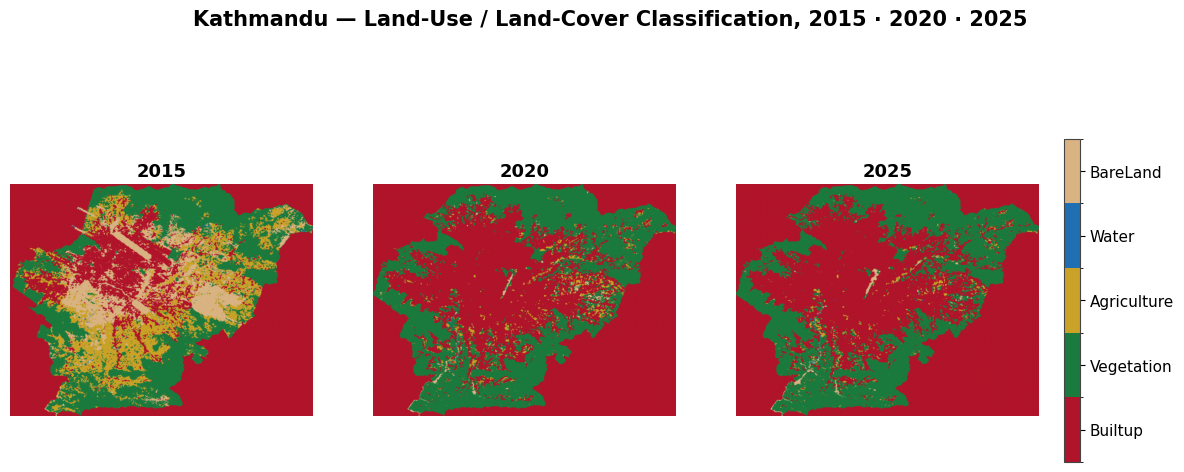

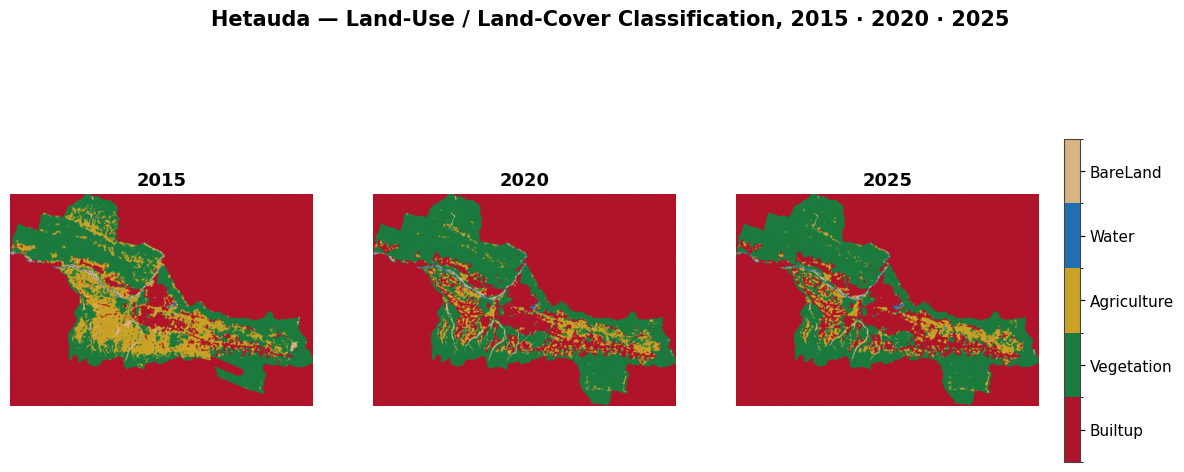

In [7]:
def categorical_cmap_norm(names: list, palette: list):
    """Build a discrete colormap + norm for N categorical classes."""
    cmap = mcolors.ListedColormap(palette[: len(names)])
    bounds = np.arange(-0.5, len(names) + 0.5, 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    return cmap, norm


def plot_year_grid(
    city: str,
    path_fn,
    class_names: list,
    palette: list,
    suptitle: str,
    savename: str,
) -> None:
    """Plot a city's classified raster for each year in YEARS, side by side."""
    fig, axes = plt.subplots(1, len(YEARS), figsize=MAP_FIGSIZE)
    cmap, norm = categorical_cmap_norm(class_names, palette)
    im = None
    for ax, year in zip(axes, YEARS):
        arr, _ = load_raster(path_fn(city, year))
        im = ax.imshow(arr, cmap=cmap, norm=norm)
        ax.set_title(str(year))
        ax.axis("off")
    cbar = fig.colorbar(im, ax=axes, ticks=range(len(class_names)), shrink=0.7, pad=0.02)
    cbar.ax.set_yticklabels(class_names)
    fig.suptitle(suptitle)
    os.makedirs(os.path.dirname(savename), exist_ok=True)
    plt.savefig(savename)
    plt.show()


for city in CITIES:
    plot_year_grid(
        city, lulc_path, CLASS_NAMES, CLASS_PALETTE,
        f"{city} \u2014 Land-Use / Land-Cover Classification, 2015 \u00b7 2020 \u00b7 2025",
        f"results/figures/{city}_LULC_maps.png",
    )


### 4b · LST maps (shared color scale across years)

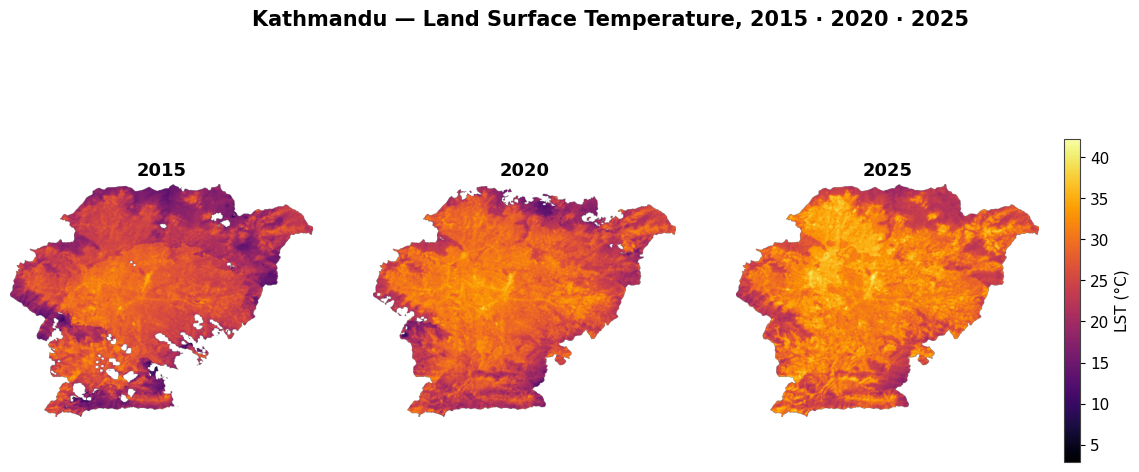

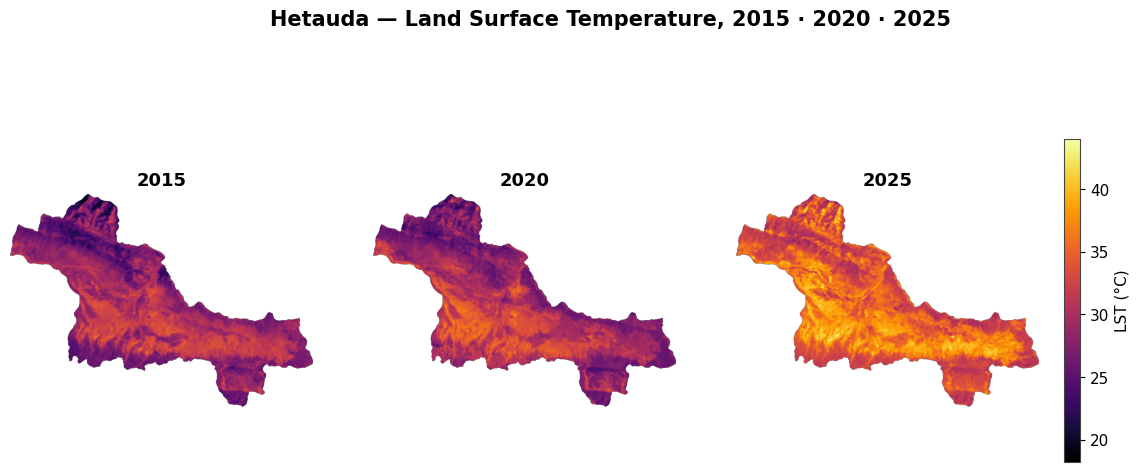

In [8]:
def plot_lst_grid(city: str) -> None:
    """Plot a city's LST raster for each year, on a shared color scale."""
    arrs = {year: load_raster(lst_path(city, year))[0] for year in YEARS}
    vmin = min(np.nanmin(a) for a in arrs.values())
    vmax = max(np.nanmax(a) for a in arrs.values())

    fig, axes = plt.subplots(1, len(YEARS), figsize=MAP_FIGSIZE)
    im = None
    for ax, year in zip(axes, YEARS):
        im = ax.imshow(arrs[year], cmap=LST_CMAP, vmin=vmin, vmax=vmax)
        ax.set_title(str(year))
        ax.axis("off")
    cbar = fig.colorbar(im, ax=axes, shrink=0.7, pad=0.02)
    cbar.set_label("LST (\u00b0C)")
    fig.suptitle(f"{city} \u2014 Land Surface Temperature, 2015 \u00b7 2020 \u00b7 2025")
    plt.savefig(f"results/figures/{city}_LST_maps.png")
    plt.show()


for city in CITIES:
    plot_lst_grid(city)


### 4c · LST difference map (2025 − 2015)

Color scale is clipped to the 2nd–98th percentile rather than the raw min/max — a handful of extreme outlier pixels (e.g. residual cloud-shadow artifacts) would otherwise wash out the real spatial pattern.

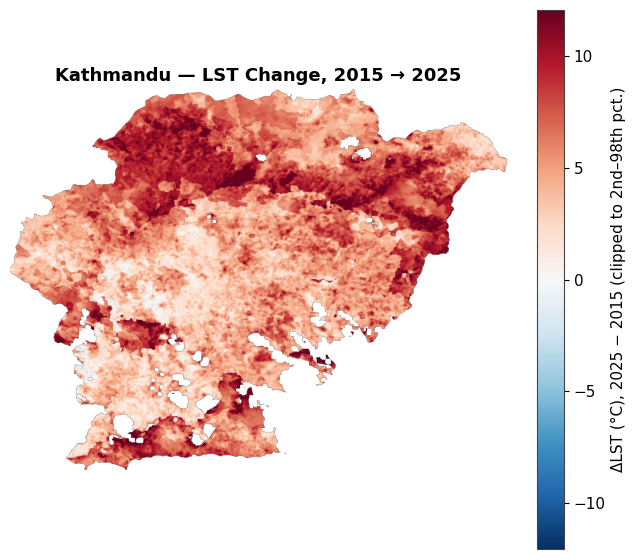

  Kathmandu: raw range [-4.3, 28.8] C   display range +/-12.1 C


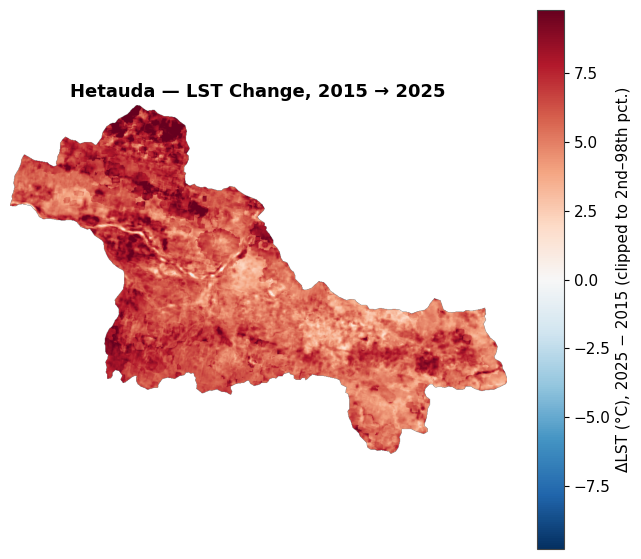

  Hetauda: raw range [-3.0, 14.8] C   display range +/-9.8 C


In [9]:
def plot_lst_difference(city: str) -> None:
    """Plot deltaLST (2025 - 2015), clipped to the 2nd-98th percentile."""
    lst_2015, _ = load_raster(lst_path(city, 2015))
    lst_2025, _ = load_raster(lst_path(city, 2025))
    diff = lst_2025 - lst_2015
    p_low, p_high = np.nanpercentile(diff, [2, 98])
    max_abs = max(abs(p_low), abs(p_high))

    plt.figure(figsize=SINGLE_MAP_FIGSIZE)
    im = plt.imshow(diff, cmap=DIFF_CMAP, vmin=-max_abs, vmax=max_abs)
    plt.colorbar(im, label="\u0394LST (\u00b0C), 2025 \u2212 2015 (clipped to 2nd\u201398th pct.)")
    plt.title(f"{city} \u2014 LST Change, 2015 \u2192 2025")
    plt.axis("off")
    plt.savefig(f"results/figures/{city}_LST_difference_map.png")
    plt.show()
    print(f"  {city}: raw range [{np.nanmin(diff):.1f}, {np.nanmax(diff):.1f}] C   "
          f"display range +/-{max_abs:.1f} C")


for city in CITIES:
    plot_lst_difference(city)


### 4d · UHI intensity zone maps

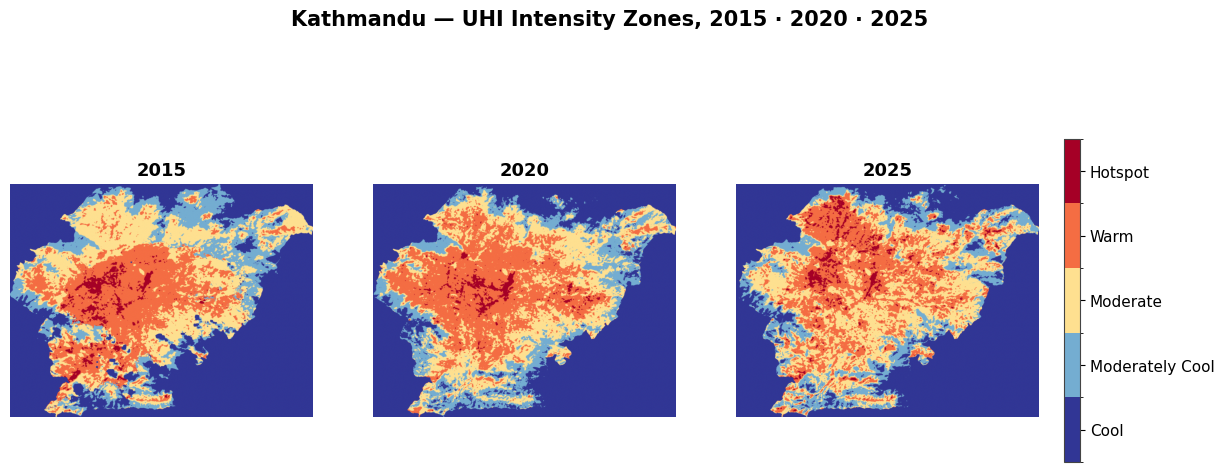

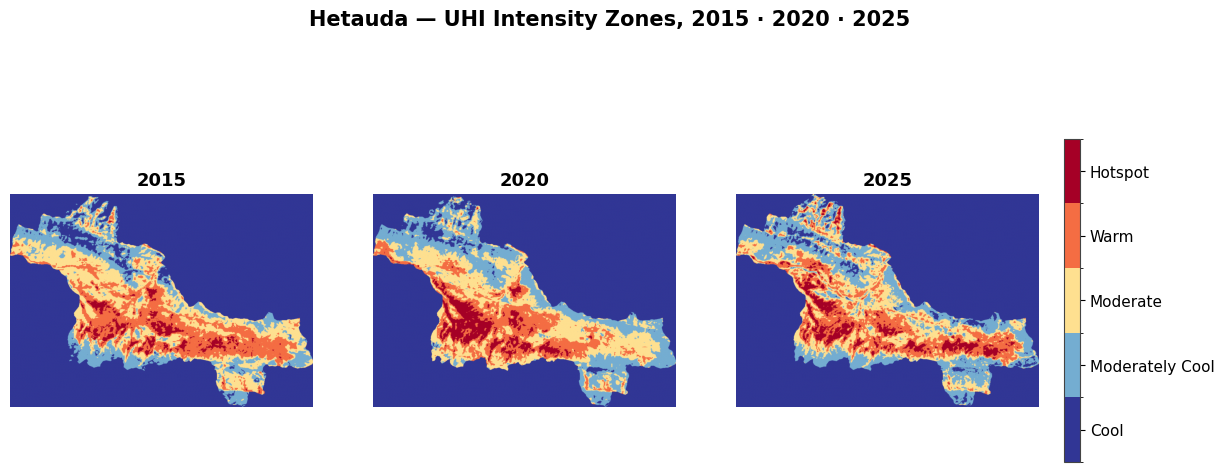

In [10]:
for city in CITIES:
    plot_year_grid(
        city, uhi_path, ZONE_NAMES, ZONE_PALETTE,
        f"{city} \u2014 UHI Intensity Zones, 2015 \u00b7 2020 \u00b7 2025",
        f"results/figures/{city}_UHI_zone_maps.png",
    )


### 4e · LULC change map (2015 → 2025), color-coded by conversion type

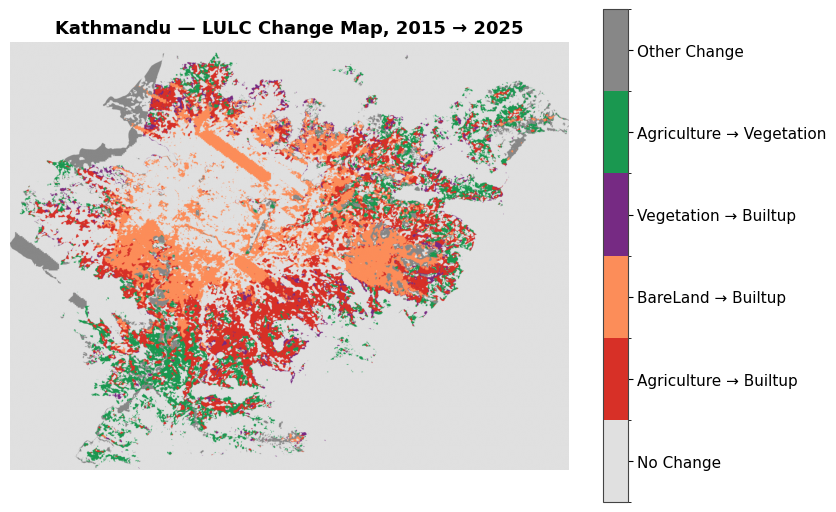

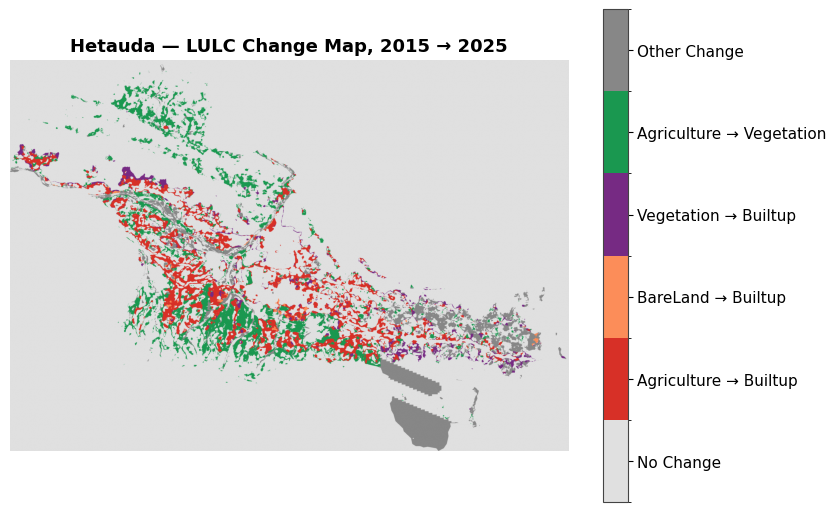

In [11]:
KEY_TRANSITIONS = {
    (2, 0): ("Agriculture \u2192 Builtup",   "#D73027"),
    (4, 0): ("BareLand \u2192 Builtup",      "#FC8D59"),
    (1, 0): ("Vegetation \u2192 Builtup",    "#762A83"),
    (2, 1): ("Agriculture \u2192 Vegetation", "#1A9850"),
}
NO_CHANGE_COLOR = "#E0E0E0"
OTHER_CHANGE_COLOR = "#878787"


def plot_change_map(city: str) -> None:
    """Highlight the key land-cover conversions between 2015 and 2025.

    Pixels are grouped into: no change, one of a handful of headline
    conversions (KEY_TRANSITIONS), or "other change" -- a catch-all for
    everything else, kept visually muted so it doesn't compete with the
    conversions that actually matter for the report.
    """
    arr_2015, _ = load_raster(lulc_path(city, 2015))
    arr_2025, _ = load_raster(lulc_path(city, 2025))

    change_map = np.full(arr_2015.shape, -1, dtype=int)
    change_map[arr_2015 == arr_2025] = 0
    legend_labels, legend_colors = ["No Change"], [NO_CHANGE_COLOR]

    for code_, ((frm, to), (label, color)) in enumerate(KEY_TRANSITIONS.items(), start=1):
        change_map[(arr_2015 == frm) & (arr_2025 == to)] = code_
        legend_labels.append(label)
        legend_colors.append(color)

    change_map[change_map == -1] = len(legend_labels)
    legend_labels.append("Other Change")
    legend_colors.append(OTHER_CHANGE_COLOR)

    cmap = mcolors.ListedColormap(legend_colors)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, len(legend_colors) + 0.5, 1), cmap.N)

    plt.figure(figsize=(9, 8))
    im = plt.imshow(change_map, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=range(len(legend_labels)), shrink=0.8)
    cbar.ax.set_yticklabels(legend_labels)
    plt.title(f"{city} \u2014 LULC Change Map, 2015 \u2192 2025")
    plt.axis("off")
    plt.savefig(f"results/figures/{city}_LULC_change_map.png")
    plt.show()


for city in CITIES:
    plot_change_map(city)


<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* **LULC maps (4a):** Kathmandu's built-up footprint is dense and contiguous by 2025, radiating outward from the historic core with little remaining open land inside the ring road. Hetauda's built-up area is comparatively sparse and linear, following the main road corridor rather than filling the whole study extent.
* **LST maps (4b):** Both cities show a clear warming shift across the three snapshots, with the hottest pixels increasingly concentrated over the built-up core rather than spread evenly across the study area.
* **LST difference map (4c):** Warming is not uniform in space — the *edges* of the existing urban footprint (where new construction is happening) show as much or more warming than the already-dense core, which had less room to get hotter. This is consistent with the LULC transition matrix (§1): peri-urban expansion zones are exactly where the largest land-cover change happened.
* **UHI zone maps (4d):** Remember these zones are classified *relative to each year's own mean/std* — a stable-looking zone map across years does not mean the city isn't warming in absolute terms (see §3, SUHII, for the absolute trend). What the zone maps do show well is the *spatial* pattern of relative heat within a given year.
* **LULC change map (4e):** Visually confirms §1's numbers — Kathmandu's conversions are dominated by Agriculture/BareLand turning into Builtup at the urban fringe; Hetauda shows a comparatively smaller, more scattered conversion footprint.

</div>

## 5 · Overlay: LULC Change vs. LST Change (answers Q4)

Compares mean LST warming (2025 − 2015) across pixels grouped by land-cover trajectory (e.g. newly built-up vs. stayed vegetated). **Read the interpretation note after this section before citing these results** — the finding here is more nuanced than a clean "urbanization causes more warming" story.

Study_Area         Trajectory  Mean_Delta_LST_C  Pixel_Count
 Kathmandu      Newly Builtup             5.820       259441
 Kathmandu     Stayed Builtup             5.754       764094
 Kathmandu  Stayed Vegetation             5.900       340311
 Kathmandu Stayed Agriculture             6.203        12249
   Hetauda      Newly Builtup             6.023        39188
   Hetauda     Stayed Builtup             5.454       569326
   Hetauda  Stayed Vegetation             6.205       163227
   Hetauda Stayed Agriculture             6.053        27995


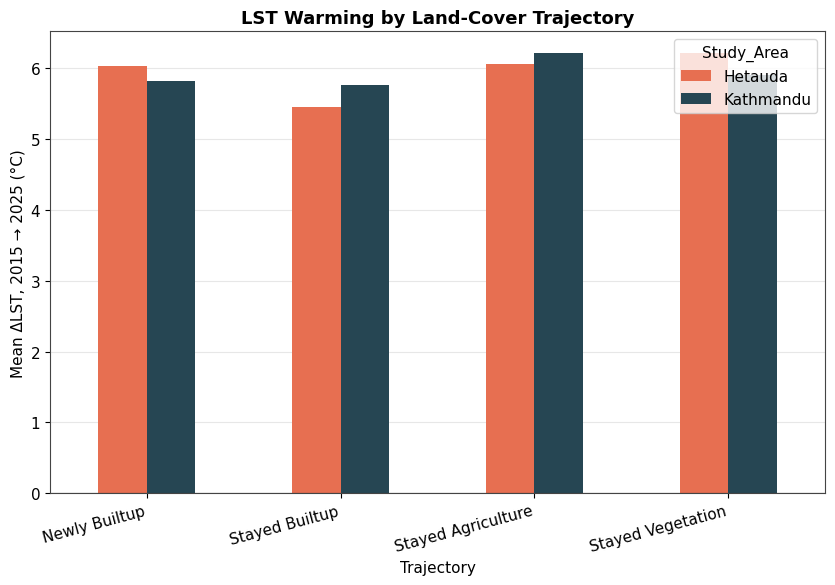

In [12]:
def compute_overlay(city: str) -> list[dict]:
    """Mean deltaLST (2025-2015) grouped by land-cover trajectory."""
    lulc_15 = align_lulc_to_lst(city, 2015)
    lulc_25 = align_lulc_to_lst(city, 2025)
    lst_15, _ = load_raster(lst_path(city, 2015))
    lst_25, _ = load_raster(lst_path(city, 2025))
    diff = lst_25 - lst_15

    groups = {
        "Newly Builtup":      (lulc_15 != 0) & (lulc_25 == 0),
        "Stayed Builtup":     (lulc_15 == 0) & (lulc_25 == 0),
        "Stayed Vegetation":  (lulc_15 == 1) & (lulc_25 == 1),
        "Stayed Agriculture": (lulc_15 == 2) & (lulc_25 == 2),
    }

    records = []
    for label, mask in groups.items():
        if mask.sum() == 0:
            continue
        mean_diff = np.nanmean(diff[mask])
        records.append({
            "Study_Area": city, "Trajectory": label,
            "Mean_Delta_LST_C": round(mean_diff, 3), "Pixel_Count": int(mask.sum()),
        })
    return records


overlay_df = pd.DataFrame([r for city in CITIES for r in compute_overlay(city)])
print(overlay_df.to_string(index=False))
overlay_df.to_csv("results/tables/LULC_LST_overlay_results.csv", index=False)

TRAJECTORY_ORDER = ["Newly Builtup", "Stayed Builtup", "Stayed Agriculture", "Stayed Vegetation"]

fig, ax = plt.subplots(figsize=(10, 6))
pivot = overlay_df.pivot(index="Trajectory", columns="Study_Area", values="Mean_Delta_LST_C")
pivot = pivot.reindex(TRAJECTORY_ORDER)
pivot.plot(kind="bar", ax=ax, color=[CITY_COLORS[c] for c in pivot.columns])
ax.set_ylabel("Mean \u0394LST, 2015 \u2192 2025 (\u00b0C)")
ax.set_title("LST Warming by Land-Cover Trajectory")
ax.axhline(0, color="#333333", linewidth=0.8)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.xticks(rotation=15, ha="right")
plt.savefig("results/figures/LULC_trajectory_warming_comparison.png")
plt.show()


> **Interpretation note.** If warming comes out roughly *uniform* across all trajectories (as it did in our run — ~5.7–6.2 °C regardless of land-cover group, in both cities), don't present that as strong Q4 evidence. A uniform citywide jump like that most likely reflects year-to-year atmospheric/seasonal differences between the specific 2015 and 2025 satellite composites, not a land-cover effect — a single-year-to-single-year comparison is exposed to that noise.
>
> **SUHII (Section 3) is the more robust metric for Q4**, since it compares urban vs. rural *within the same year*, which cancels out most of that inter-annual noise by construction. Lead with SUHII and the transition matrices for the report's Q4 answer; treat this overlay as a secondary, more caveated observation.

## 6 · Charts from the Pre-Built CSVs (area trend, LST-by-class)

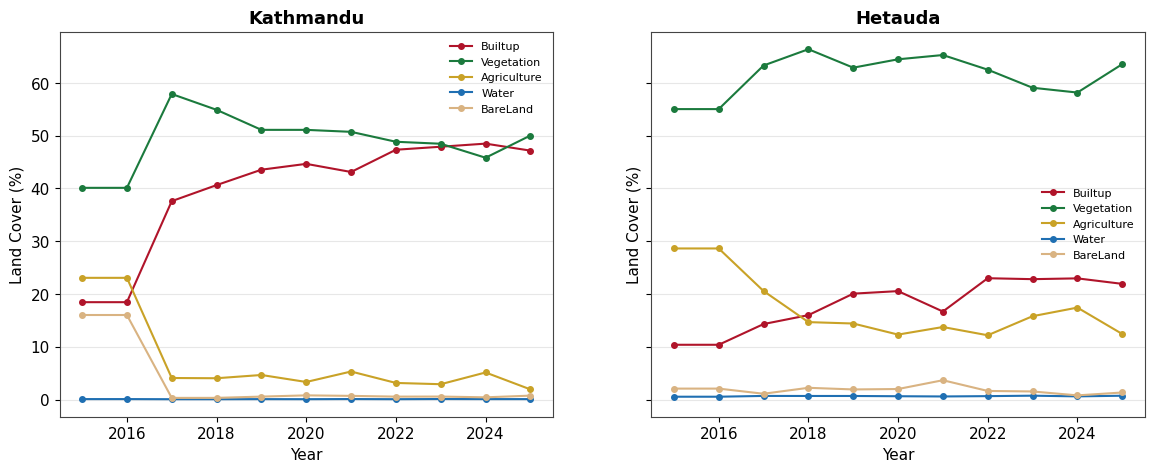

In [13]:
def plot_area_trend() -> None:
    """Land-cover share (%) over time, per city, one line per class."""
    fig, axes = plt.subplots(1, len(CITIES), figsize=(14, 5), sharey=True)
    for ax, city in zip(axes, CITIES):
        df = pd.read_csv(f"../data/{city.lower()}/csv/LULC_Area_Stats_{city}.csv")
        for cls in CLASS_NAMES:
            ax.plot(df["Year"], df[f"{cls}_Percent"], marker="o", markersize=4,
                     label=cls, color=CLASS_COLORS[cls])
        ax.set_title(city)
        ax.set_xlabel("Year")
        ax.set_ylabel("Land Cover (%)")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.legend(fontsize=8, frameon=False)
    plt.savefig("results/figures/LULC_area_trend.png")
    plt.show()


plot_area_trend()


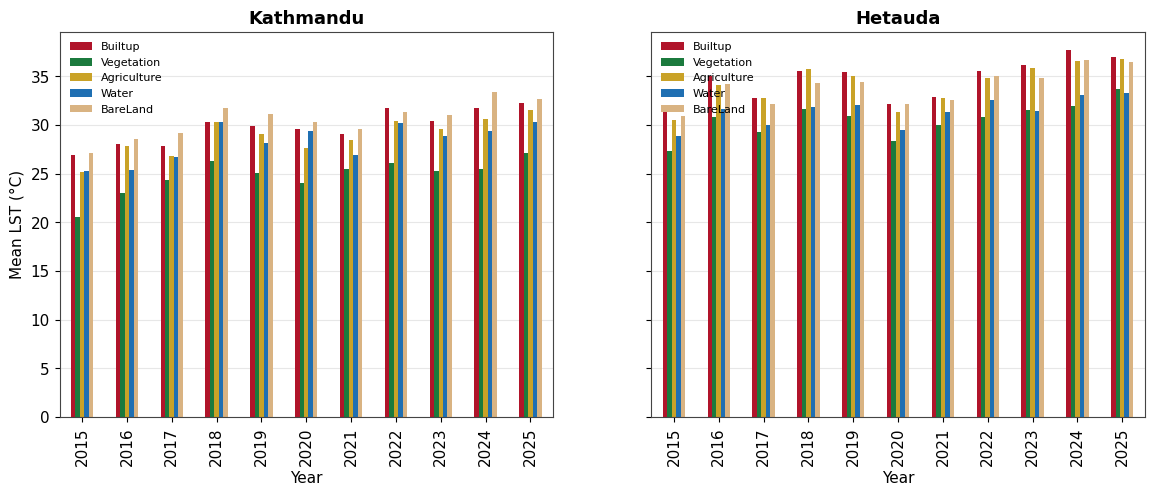

Builtup - Vegetation LST gap trend
---------------------------------------------
  Kathmandu    6.34C (2015) -> 5.14C (2025)
  Hetauda      4.02C (2015) -> 3.34C (2025)


In [14]:
def plot_lst_by_class() -> None:
    """Mean LST per land-cover class over time, per city."""
    fig, axes = plt.subplots(1, len(CITIES), figsize=(14, 5), sharey=True)
    for ax, city in zip(axes, CITIES):
        df = pd.read_csv(f"../data/{city.lower()}/csv/LULC_LST_Relationship_{city}.csv")
        pivot = df.pivot(index="Year", columns="LULC_Class", values="Mean_LST")
        pivot = pivot[[c for c in CLASS_NAMES if c in pivot.columns]]
        pivot.plot(kind="bar", ax=ax, color=[CLASS_COLORS[c] for c in pivot.columns])
        ax.set_title(city)
        ax.set_ylabel("Mean LST (\u00b0C)")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.legend(fontsize=8, frameon=False)
    plt.savefig("results/figures/LST_by_LULC_class.png")
    plt.show()

    print("Builtup - Vegetation LST gap trend")
    print("-" * 45)
    for city in CITIES:
        df = pd.read_csv(f"../data/{city.lower()}/csv/LULC_LST_Relationship_{city}.csv")
        pivot = df.pivot(index="Year", columns="LULC_Class", values="Mean_LST")
        gap = pivot["Builtup"] - pivot["Vegetation"]
        print(f"  {city:<12s} {gap.iloc[0]:.2f}C ({pivot.index[0]}) -> "
              f"{gap.iloc[-1]:.2f}C ({pivot.index[-1]})")


plot_lst_by_class()


<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* **LULC area trend:** Both cities show Builtup share rising steadily across the full 2015–2025 span (not just the three snapshot years), with the steepest increase occurring in the second half of the decade for both cities.
* **LST by LULC class:** In both cities, Builtup and BareLand pixels run consistently hotter than Vegetation and Water across every year — the physical ordering expected from UHI theory holds throughout the whole study period, which is a good internal-consistency check on the data.
* **Builtup–Vegetation gap trend:** the printed gap values show whether the *thermal penalty* of urbanization (not just its extent) is widening or narrowing over time — a narrowing gap despite growing Builtup extent would suggest other factors (e.g. green infrastructure, tree cover retention) are partially offsetting the heat effect, which is worth highlighting explicitly if it appears in your printed output above.

</div>

## Summary

**What each section answers:**

| Section | Answers | Notes |
|---|---|---|
| §1 LULC transition matrix | **Q1** — exactly which classes converted to Builtup | direct pixel-level evidence |
| §3 SUHII trend | **Q2 / Q4** — is the heat island intensifying? | most robust metric (within-year comparison) |
| §2 UHI zone transition matrix | **Q2** — spatial shift into hotter zones | mirrors §1, applied to heat zones |
| §4 Maps | — | figures for the written report |
| §5 LULC × LST overlay | **Q4** (secondary) — does new built-up area warm the most? | caveated — see interpretation note above |

**Files written to the working directory:**
- `{City}_LULC_transition_matrix.csv`, `{City}_UHI_zone_transition_matrix.csv`
- `SUHII_results.csv`, `LULC_LST_overlay_results.csv`
- `{City}_LULC_maps.png`, `{City}_LST_maps.png`, `{City}_LST_difference_map.png`, `{City}_UHI_zone_maps.png`, `{City}_LULC_change_map.png`
- `LULC_area_trend.png`, `LST_by_LULC_class.png`, `LULC_trajectory_warming_comparison.png`

**Reporting guidance:** lead with SUHII (§3) and the transition matrices (§1–2) as the primary Q2/Q4 evidence; treat the overlay (§5) as a secondary, caveated observation rather than proof of causation.

## 7 · Additional Diagnostics

Three figures that use data already computed above, but were not originally plotted: the SUHII trend as an actual chart (§3 only printed a table), the UHI zone area breakdown across all three years (mirrors §1's area-trend chart, applied to heat zones), and the true pixel-level LST distribution by land-cover class (§6 only showed the *mean*, this shows the full spread).

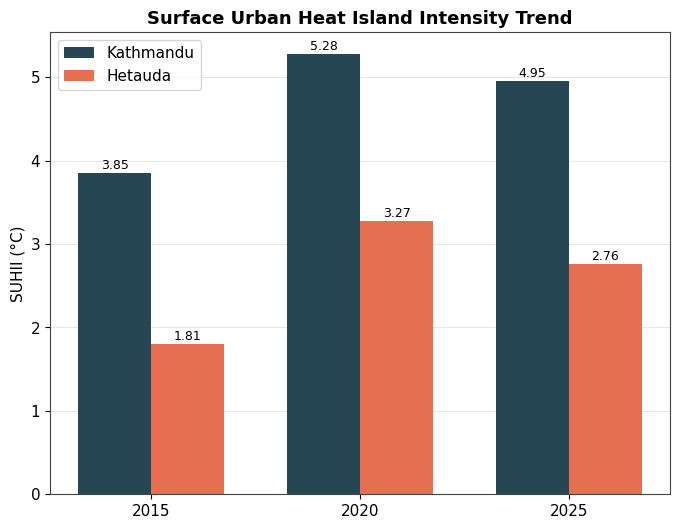

In [15]:
# ── 7a. SUHII trend chart (data already computed in §3, never plotted) ──────
suhii_df = pd.read_csv("results/tables/SUHII_results.csv")

fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35
x = np.arange(len(YEARS))
for i, city in enumerate(CITIES):
    sub = suhii_df[suhii_df["Study_Area"] == city].sort_values("Year")
    ax.bar(x + i * width, sub["SUHII_C"], width, label=city, color=CITY_COLORS[city])
    for xi, val in zip(x + i * width, sub["SUHII_C"]):
        ax.text(xi, val + 0.05, f"{val:.2f}", ha="center", fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(YEARS)
ax.set_ylabel("SUHII (°C)")
ax.set_title("Surface Urban Heat Island Intensity Trend")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.savefig("results/figures/SUHII_trend_chart.png")
plt.show()

<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* SUHII does **not** rise monotonically in either city — it peaks around 2020 before easing slightly by 2025 (Kathmandu: 3.85 → 5.28 → 4.95 °C; Hetauda: 1.81 → 3.27 → 2.76 °C). Report this honestly as "intensified through 2020, moderating somewhat by 2025, remaining well above the 2015 baseline" rather than claiming a clean steady increase.
* Kathmandu's SUHII is consistently higher than Hetauda's across all three years, consistent with its denser, more established urban core.

</div>

Study_Area  Year            Zone  Area_km2  Percent
 Kathmandu  2015            Cool    556.94    46.43
 Kathmandu  2015 Moderately Cool    150.31    12.53
 Kathmandu  2015        Moderate    248.48    20.71
 Kathmandu  2015            Warm    218.82    18.24
 Kathmandu  2015         Hotspot     25.01     2.08
 Kathmandu  2020            Cool    550.18    45.86
 Kathmandu  2020 Moderately Cool    151.29    12.61
 Kathmandu  2020        Moderate    229.66    19.15
 Kathmandu  2020            Warm    251.10    20.93
 Kathmandu  2020         Hotspot     17.34     1.45
 Kathmandu  2025            Cool    543.23    45.29
 Kathmandu  2025 Moderately Cool    143.48    11.96
 Kathmandu  2025        Moderate    259.16    21.60
 Kathmandu  2025            Warm    226.59    18.89
 Kathmandu  2025         Hotspot     27.11     2.26
   Hetauda  2015            Cool    446.36    64.53
   Hetauda  2015 Moderately Cool     64.26     9.29
   Hetauda  2015        Moderate     93.39    13.50
   Hetauda  

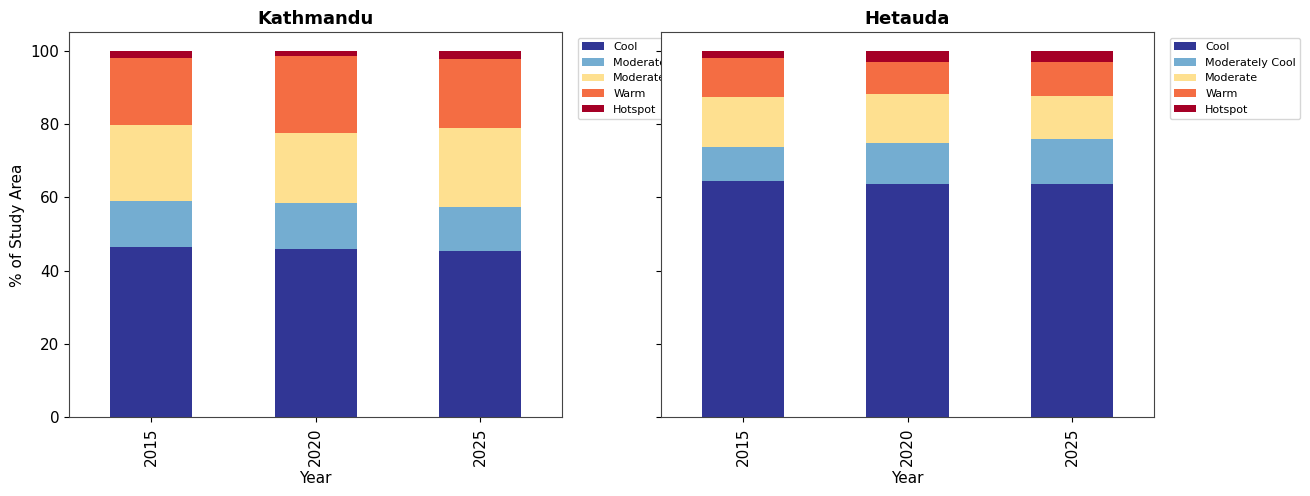

In [16]:
# ── 7b. UHI zone area trend (mirrors §1's LULC area-trend chart) ────────────
zone_records = []
for city in CITIES:
    for year in YEARS:
        arr, px_area = load_raster(uhi_path(city, year))
        vals, counts = np.unique(arr, return_counts=True)
        total_pixels = arr.size
        for v, c in zip(vals, counts):
            if 0 <= v < len(ZONE_NAMES):
                zone_records.append({
                    "Study_Area": city, "Year": year, "Zone": ZONE_NAMES[int(v)],
                    "Area_km2": round(c * px_area, 2),
                    "Percent": round(100 * c / total_pixels, 2),
                })

zone_area_df = pd.DataFrame(zone_records)
zone_area_df.to_csv("results/tables/UHI_Zone_Area_Stats.csv", index=False)
print(zone_area_df.to_string(index=False))

fig, axes = plt.subplots(1, len(CITIES), figsize=(14, 5), sharey=True)
for ax, city in zip(axes, CITIES):
    sub = zone_area_df[zone_area_df["Study_Area"] == city]
    pivot = sub.pivot(index="Year", columns="Zone", values="Percent")
    pivot = pivot[[z for z in ZONE_NAMES if z in pivot.columns]]
    pivot.plot(kind="bar", stacked=True, ax=ax, color=[ZONE_COLORS[z] for z in pivot.columns])
    ax.set_title(city)
    ax.set_ylabel("% of Study Area")
    ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig("results/figures/UHI_zone_area_trend.png")
plt.show()

<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* **Important methodological note**: this classification uses each year's own mean/std as thresholds, so it is *self-normalizing* — the zone percentages stay fairly stable across years by construction, even though the city is genuinely warming (see §3/§7a for the absolute trend). **Do not read a stable zone-area chart as evidence the city isn't heating up** — it answers a different question ("where is heat concentrated, relative to that year") than SUHII does ("how much hotter is urban than rural, in absolute °C").
* State this distinction explicitly in the report so the zone-area chart and the SUHII chart don't read as contradicting each other.

</div>

/tmp/ipykernel_587/3337519018.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False)
/tmp/ipykernel_587/3337519018.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False)


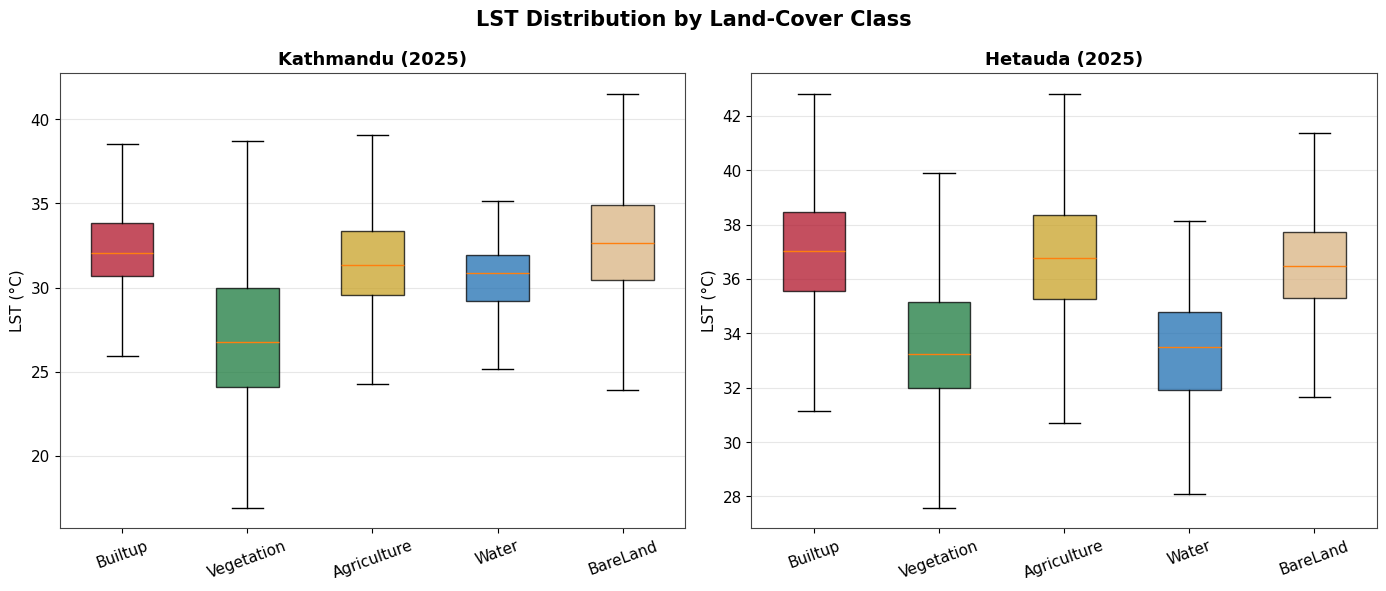

In [17]:
# ── 7c. Pixel-level LST distribution by LULC class (boxplot) ────────────────
# §6's chart only showed the MEAN LST per class from the CSV. This uses the
# actual rasters to show the full distribution, which is more statistically
# honest and a stronger figure for the report.
fig, axes = plt.subplots(1, len(CITIES), figsize=(14, 6))
for ax, city in zip(axes, CITIES):
    lst_arr, _ = load_raster(lst_path(city, 2025))
    lulc_aligned = align_lulc_to_lst(city, 2025)

    box_data, box_labels = [], []
    for code_, name in enumerate(CLASS_NAMES):
        values = lst_arr[lulc_aligned == code_]
        values = values[~np.isnan(values)]
        if len(values) > 0:
            if len(values) > 20000:
                values = np.random.choice(values, 20000, replace=False)
            box_data.append(values)
            box_labels.append(name)

    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False)
    for patch, name in zip(bp["boxes"], box_labels):
        patch.set_facecolor(CLASS_COLORS[name])
        patch.set_alpha(0.75)
    ax.set_title(f"{city} (2025)")
    ax.set_ylabel("LST (°C)")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("LST Distribution by Land-Cover Class")
plt.tight_layout()
plt.savefig("results/figures/LST_distribution_by_class_boxplot.png")
plt.show()

<div style="background-color: #f0f4f8; border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Clear separation between hot classes (Builtup, BareLand) and cool classes (Vegetation, Water) in both cities, with visible overlap in the interquartile ranges — this nuance (some Vegetation pixels run as hot as the coolest Builtup pixels, and vice versa) is exactly what the mean-only bar chart in §6 hides.
* Use this boxplot as the primary Chapter 5 figure for "LST by land cover" and keep §6's bar chart as a secondary/simpler summary if space is limited.

</div>